# Tutorial 4: Fitting with MAP Optimization

This tutorial demonstrates fitting mock galaxies using diffsed's gradient-based MAP optimization. We show:
1. **Photometry-only** fitting (5 SDSS bands)
2. **Parameter fixing** — fix some parameters, fit others
3. **SNR dependence** — how noise level affects recovery
4. **Batch mock generation** — sample from priors, generate many galaxies
5. **Fitter API** — direct control for chaining MAP to NUTS

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, "../src")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import time

from diffsed import (
    Model, ParamSpec, Fitter, Uniform, Gaussian, Fixed,
    load_ssp_data, load_filter_set,
)

plt.rcParams.update({
    "figure.dpi": 130, "font.size": 11,
    "axes.linewidth": 1.0,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
})

ssp = load_ssp_data("../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
filter_names = ["u", "g", "r", "i", "z"]

---
## 1. Photometric Fitting

Define a parametric model (no stochastic SFH) and fit a mock galaxy with MAP. The `ParamSpec` sets which parameters are free (`Uniform(lo, hi)`) and which are fixed (scalar values).

In [2]:
spec = ParamSpec(
    sfh_alpha        = Uniform(0.5, 3.0),
    sfh_beta         = Uniform(0.3, 2.0),
    sfh_tau_peak_gyr = Uniform(0.5, 10.0),
    sfh_peak_sfr     = Uniform(0.1, 50.0),
    met_logzsol      = Uniform(-1.5, 0.2),
    dust_tau_bc      = Uniform(0.0, 3.0),
    dust_tau_diff    = Uniform(0.0, 2.0),
    dust_slope       = -0.7,
    redshift         = 0.1,
    stochastic       = False,
)

model = Model(spec, ssp, filters=filters)

true_params = {
    "sfh_alpha": 1.5, "sfh_beta": 1.0,
    "sfh_tau_peak_gyr": 4.0, "sfh_peak_sfr": 8.0,
    "met_logzsol": -0.3,
    "dust_tau_bc": 1.0, "dust_tau_diff": 0.3,
    "dust_slope": -0.7, "redshift": 0.1,
}

mock = model.mock(true_params, snr=20.0, key=jax.random.PRNGKey(0))

result = model.fit(
    mock.flux_obs, mock.noise,
    method="map", n_steps=2000, learning_rate=0.03, verbose=True,
)

W0313 21:33:10.999846 2569631 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


  Step     0/2000: loss = 193.4303


  Step   200/2000: loss = 2.0148


  Step   400/2000: loss = 1.9841


  Step   600/2000: loss = 1.9458


...

  Step  1200/2000: loss = 1.7992


  Step  1400/2000: loss = 1.7430


  Step  1600/2000: loss = 1.6857


  Step  1800/2000: loss = 1.6290


  Step  1999/2000: loss = 1.5753
  MAP complete in 3.7s


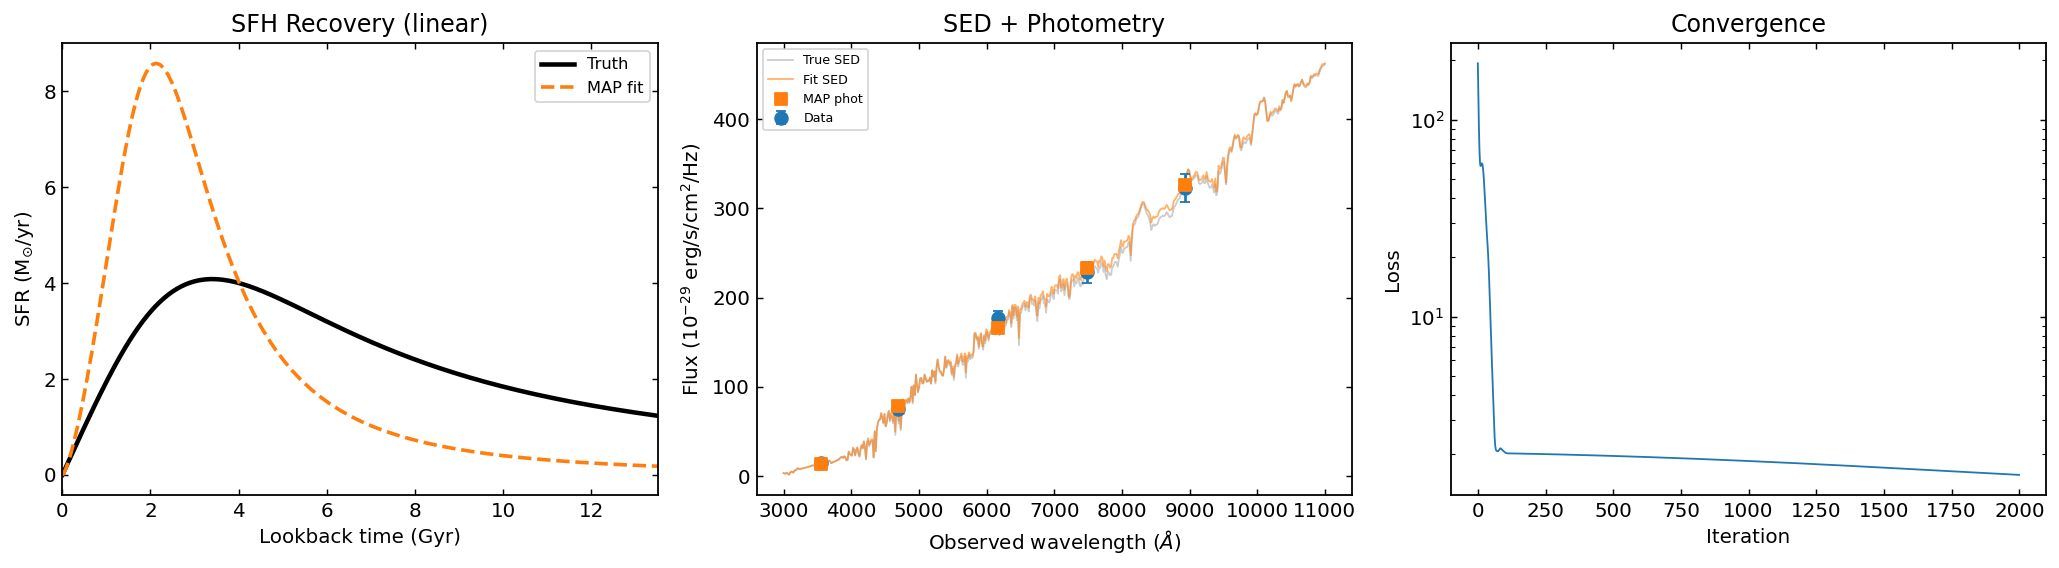

Parameter                  True      Fit
----------------------------------------
dust_slope                 -0.7     -0.7
dust_tau_bc                   1   0.0825
dust_tau_diff               0.3    0.657
met_logzsol                -0.3   -0.664
redshift                    0.1      0.1
sfh_alpha                   1.5     2.66
sfh_beta                      1     1.41
sfh_peak_sfr                  8     16.3
sfh_tau_peak_gyr              4     2.49


In [3]:
# Results
sfh_true = model.predict_sfh(true_params)
sfh_fit = model.predict_sfh(result.params)
phot_fit = model.predict_photometry(result.params)

# SED for background
wave_obs = jnp.linspace(3000, 11000, 500)
sed_true = model.predict_spectrum(true_params, wave_obs)
sed_fit = model.predict_spectrum(result.params, wave_obs)
wave_eff = jnp.array([3551, 4686, 6166, 7480, 8932])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# SFH (linear)
ax = axes[0]
ax.plot(sfh_true["t_gyr"], sfh_true["sfr_mean"], "k-", lw=2.5, label="Truth")
ax.plot(sfh_fit["t_gyr"], sfh_fit["sfr_mean"], "C1--", lw=2, label="MAP fit")
ax.set_xlabel("Lookback time (Gyr)")
ax.set_ylabel(r"SFR (M$_{\odot}$/yr)")
ax.set_title("SFH Recovery (linear)")
ax.set_xlim(0, 13.5)
ax.legend(fontsize=9)

# SED + photometry
ax = axes[1]
ax.plot(wave_obs, sed_true * 1e29, color="gray", alpha=0.4, lw=1, label="True SED")
ax.plot(wave_obs, sed_fit * 1e29, color="C1", alpha=0.6, lw=1, label="Fit SED")
ax.errorbar(wave_eff, mock.flux_obs * 1e29, yerr=mock.noise * 1e29,
             fmt="o", color="C0", ms=7, capsize=3, label="Data")
ax.scatter(wave_eff, phot_fit * 1e29, color="C1", marker="s", s=50, zorder=10, label="MAP phot")
ax.set_xlabel(r"Observed wavelength ($\AA$)")
ax.set_ylabel(r"Flux ($10^{-29}$ erg/s/cm$^2$/Hz)")
ax.set_title("SED + Photometry")
ax.legend(fontsize=7)

# Loss
ax = axes[2]
ax.plot(result.loss_history, "C0", lw=1)
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_title("Convergence")

plt.tight_layout()
plt.show()

# Parameter table
summary = result.summary()
print(f"{'Parameter':<22s} {'True':>8s} {'Fit':>8s}")
print("-" * 40)
for name in sorted(true_params.keys()):
    if name in summary:
        print(f"{name:<22s} {true_params[name]:>8.3g} {summary[name]['value']:>8.3g}")

---
## 2. Parameter Fixing

Fix dust and metallicity to their known values. With fewer free parameters, the SFH recovery improves because there's less age-dust-metallicity degeneracy.

Free: 4 params (was 7)


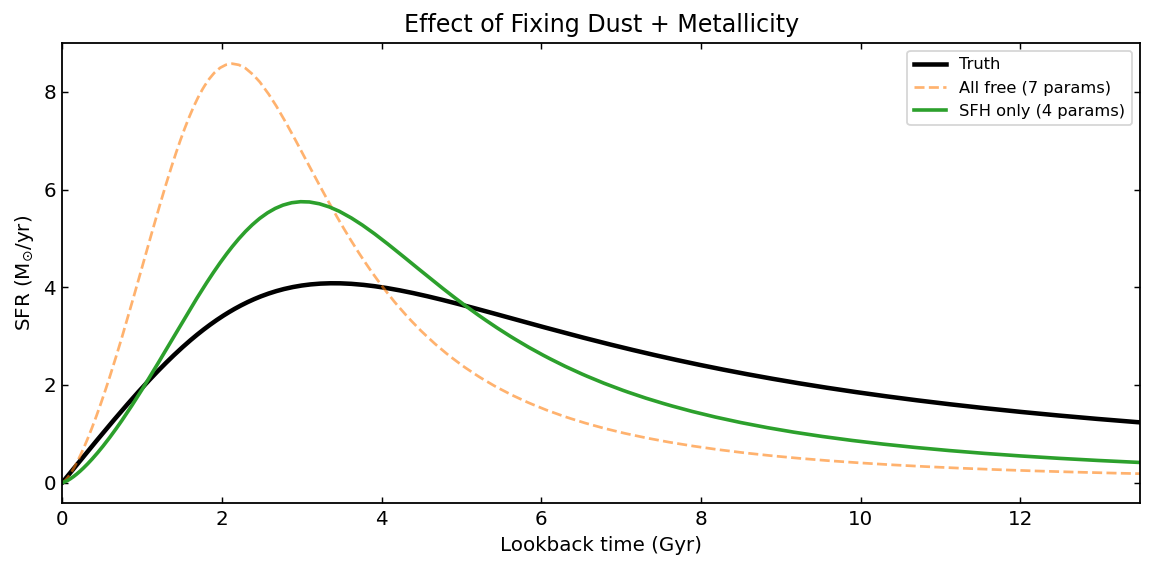

In [4]:
spec_fixed = ParamSpec(
    sfh_alpha        = Uniform(0.5, 3.0),
    sfh_beta         = Uniform(0.3, 2.0),
    sfh_tau_peak_gyr = Uniform(0.5, 10.0),
    sfh_peak_sfr     = Uniform(0.1, 50.0),
    met_logzsol      = -0.3,       # FIXED
    dust_tau_bc      = 1.0,        # FIXED
    dust_tau_diff    = 0.3,        # FIXED
    dust_slope       = -0.7,
    redshift         = 0.1,
    stochastic       = False,
)
model_fixed = Model(spec_fixed, ssp, filters=filters)

print(f"Free: {spec_fixed.n_free} params (was {spec.n_free})")

result_fixed = model_fixed.fit(
    mock.flux_obs, mock.noise,
    method="map", n_steps=1500, verbose=False,
)

sfh_fixed = model_fixed.predict_sfh(result_fixed.params)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sfh_true["t_gyr"], sfh_true["sfr_mean"], "k-", lw=2.5, label="Truth")
ax.plot(sfh_fit["t_gyr"], sfh_fit["sfr_mean"], "C1--", lw=1.5,
        label=f"All free ({spec.n_free} params)", alpha=0.6)
ax.plot(sfh_fixed["t_gyr"], sfh_fixed["sfr_mean"], "C2-", lw=2,
        label=f"SFH only ({spec_fixed.n_free} params)")
ax.set_xlabel("Lookback time (Gyr)")
ax.set_ylabel(r"SFR (M$_{\odot}$/yr)")
ax.set_title("Effect of Fixing Dust + Metallicity")
ax.set_xlim(0, 13.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. SNR Dependence

SNR= 5: loss=2.3, time=2.9s


SNR=10: loss=1.4, time=2.9s


SNR=20: loss=0.5, time=2.9s


SNR=50: loss=2.6, time=2.9s


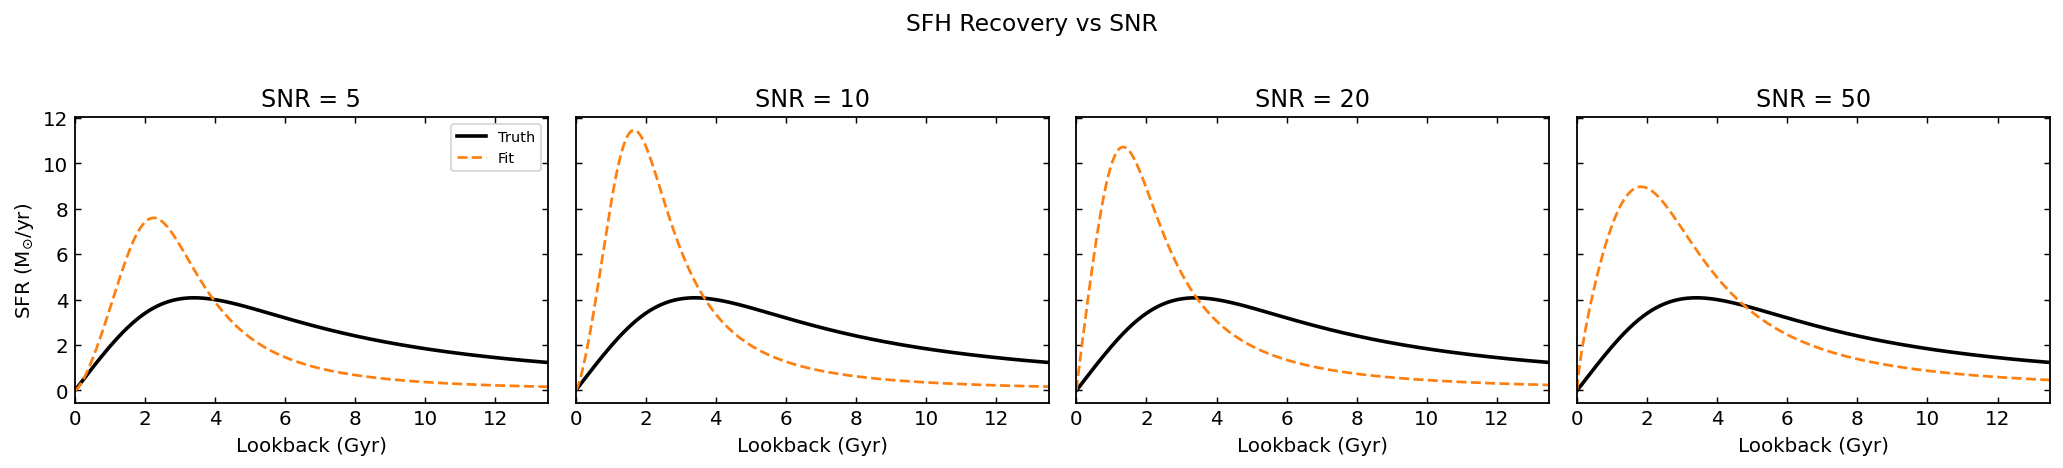

In [5]:
snr_values = [5, 10, 20, 50]
results_snr = {}

for snr in snr_values:
    m = model.mock(true_params, snr=snr, key=jax.random.PRNGKey(int(snr)))
    r = model.fit(m.flux_obs, m.noise, method="map", n_steps=1500, verbose=False)
    results_snr[snr] = r
    print(f"SNR={snr:2d}: loss={r.diagnostics['final_loss']:.1f}, time={r.wall_time_s:.1f}s")

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for ax, snr in zip(axes, snr_values):
    sfh_s = model.predict_sfh(results_snr[snr].params)
    ax.plot(sfh_true["t_gyr"], sfh_true["sfr_mean"], "k-", lw=2, label="Truth")
    ax.plot(sfh_s["t_gyr"], sfh_s["sfr_mean"], "C1--", lw=1.5, label="Fit")
    ax.set_xlabel("Lookback (Gyr)")
    ax.set_title(f"SNR = {snr}")
    ax.set_xlim(0, 13.5)
    if ax == axes[0]:
        ax.set_ylabel(r"SFR (M$_{\odot}$/yr)")
        ax.legend(fontsize=8)
plt.suptitle("SFH Recovery vs SNR", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Batch Mock Generation

In [6]:
# Sample 10 galaxies from the prior
param_batch = spec.sample_batch(jax.random.PRNGKey(42), n=10)
mock_batch = model.mock_batch(param_batch, snr=20.0, key=jax.random.PRNGKey(43))

print(f"Generated {mock_batch.flux_true.shape[0]} galaxies, "
      f"{mock_batch.flux_true.shape[1]} bands each")

# Fit each
batch_results = []
t0 = time.time()
for i in range(10):
    r = model.fit(mock_batch.flux_obs[i], mock_batch.noise[i],
                  method="map", n_steps=1500, verbose=False)
    batch_results.append(r)
total = time.time() - t0
print(f"Fit 10 galaxies in {total:.1f}s ({total/10:.1f}s each)")

Generated 10 galaxies, 5 bands each


Fit 10 galaxies in 29.2s (2.9s each)


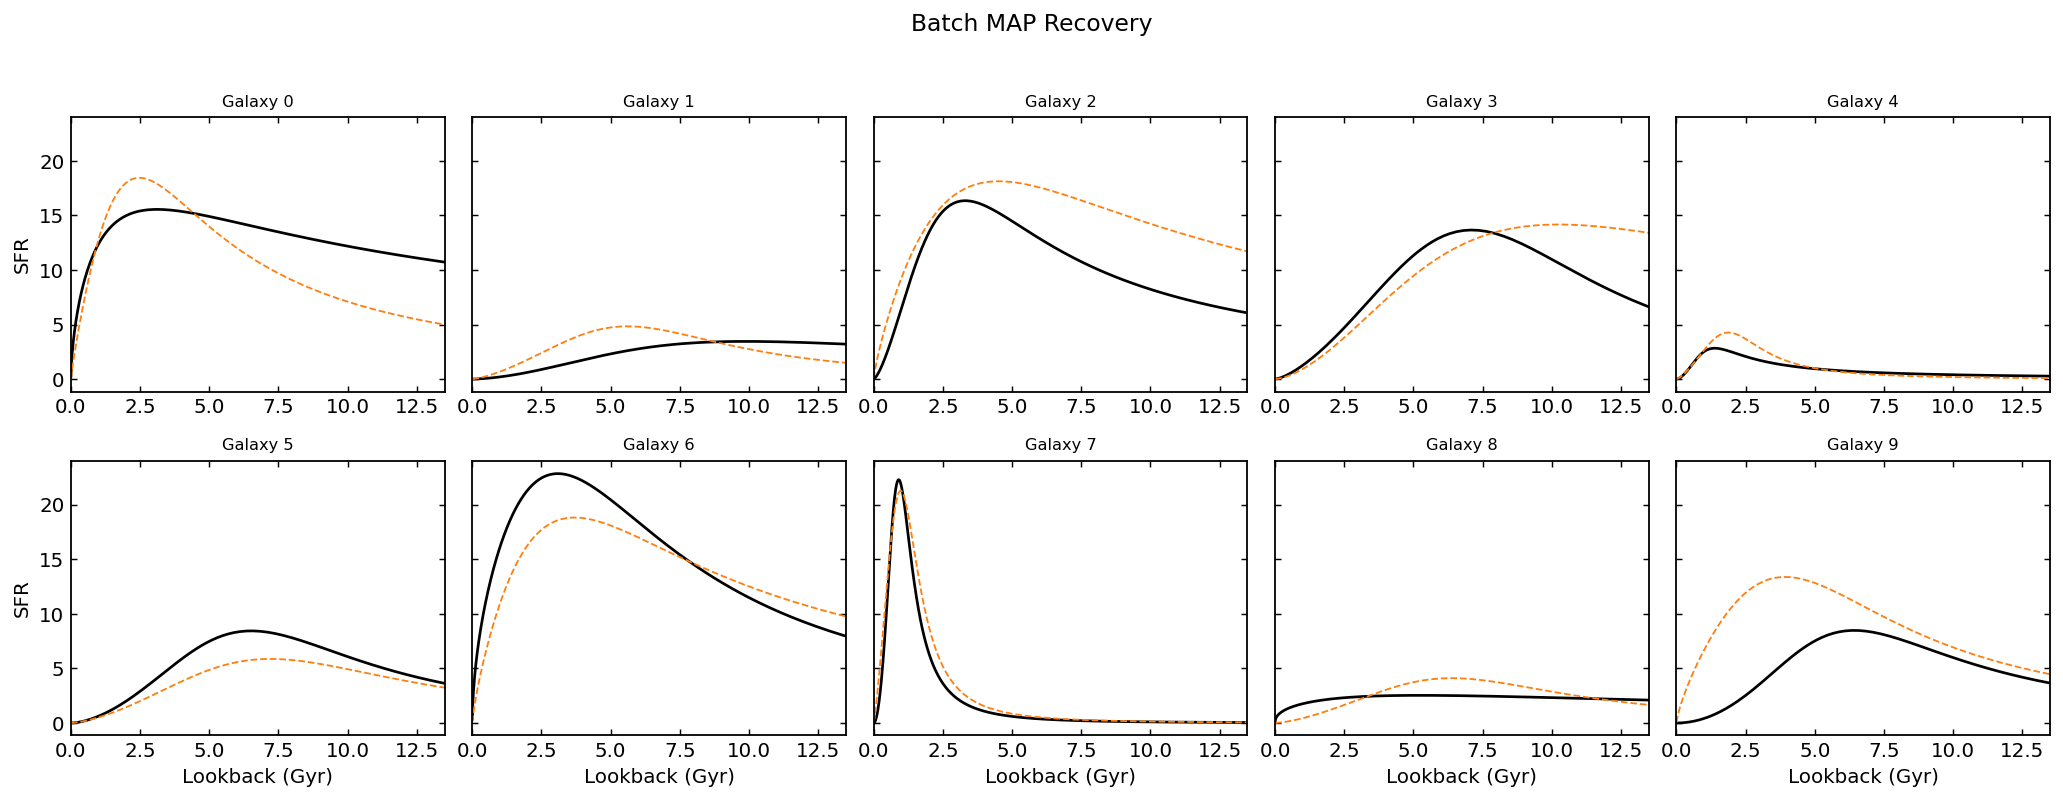

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharey=True)
for idx, (ax, res) in enumerate(zip(axes.ravel(), batch_results)):
    true_i = {k: v[idx] for k, v in param_batch.items()}
    sfh_t = model.predict_sfh(true_i)
    sfh_f = model.predict_sfh(res.params)
    ax.plot(sfh_t["t_gyr"], sfh_t["sfr_mean"], "k-", lw=1.5)
    ax.plot(sfh_f["t_gyr"], sfh_f["sfr_mean"], "C1--", lw=1)
    ax.set_xlim(0, 13.5)
    ax.set_title(f"Galaxy {idx}", fontsize=9)
    if idx % 5 == 0: ax.set_ylabel("SFR")
    if idx >= 5: ax.set_xlabel("Lookback (Gyr)")
plt.suptitle("Batch MAP Recovery", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Using the Fitter Directly

For chaining methods (e.g., MAP initialization for NUTS), use `Fitter` explicitly.

In [8]:
fitter = Fitter(model, mock.flux_obs, mock.noise)

# MAP first
r_map = fitter.run("map", n_steps=1000, verbose=False)
print(f"MAP: loss={r_map.diagnostics['final_loss']:.2f}, time={r_map.wall_time_s:.1f}s")

# Chain to NUTS
try:
    r_nuts = fitter.run("nuts", init_from=r_map, n_warmup=100, n_samples=50, verbose=True)
    print(f"NUTS: divergences={r_nuts.diagnostics['n_divergent']}, time={r_nuts.wall_time_s:.1f}s")
except ImportError:
    print("BlackJAX not installed")

MAP: loss=1.92, time=2.2s


NUTS: 7 parameters, 100 warmup, 50 samples


  Warmup complete (2.1s). Step size: 0.0789


  Sample 50/50
  NUTS complete in 135.8s. Divergences: 28/50
NUTS: divergences=28, time=135.8s


---
## 6. Derived Quantities

In [9]:
d_true = model.predict_derived(true_params)
d_fit = model.predict_derived(result.params)

print(f"{'Quantity':<20s} {'True':>12s} {'Fit':>12s} {'Units'}")
print("-" * 60)
print(f"{'stellar_mass':<20s} {float(d_true['stellar_mass']):>12.3e} {float(d_fit['stellar_mass']):>12.3e} {'Msun'}")
print(f"{'sfr_100myr':<20s} {float(d_true['sfr_100myr']):>12.3f} {float(d_fit['sfr_100myr']):>12.3f} {'Msun/yr'}")
print(f"{'ssfr':<20s} {float(d_true['ssfr']):>12.3e} {float(d_fit['ssfr']):>12.3e} {'yr^-1'}")

Quantity                     True          Fit Units
------------------------------------------------------------
stellar_mass            3.361e+10    3.127e+10 Msun
sfr_100myr                  0.043        0.027 Msun/yr
ssfr                    1.286e-12    8.721e-13 yr^-1


---
## Key Takeaways

1. **`ParamSpec` controls everything**: what's free, what's fixed, and the prior bounds
2. **Fixing parameters** reduces dimensionality and improves SFH recovery
3. **Higher SNR** constrains the fit better, but gains flatten past SNR ~ 20
4. **Batch fitting** via `mock_batch` + loop; full `vmap` parallelization for production
5. **`Fitter`** gives direct control for chaining MAP -> NUTS
6. **Derived quantities** (M*, SFR, sSFR) are computed from the fitted SFH, not as free parameters